# 4. Performance Evaluation Pipeline for JobStreet Dataset

This notebook performs a comprehensive performance evaluation and benchmarking of the optimization techniques applied to the JobStreet dataset.

We measure and compare four approaches across execution time and system resource utilization:
1. **Baseline Pandas:** Standard, unoptimized sequential data loading and aggregation.
2. **Optimized Pandas:** Memory-optimized pipeline using explicit datatypes and column pruning.
3. **Polars Lazy Execution:** Multi-threaded, Rust-backed lazy evaluation pipeline.
4. **DuckDB SQL-Based Processing:** High-performance vectorized OLAP database processing.

The objective is to quantitatively analyze efficiency gains in terms of **Execution Latency** and **Memory Spikes**.

### Import Libraries and Configure Paths

In [16]:
# Install required libraries if not already available in the environment
!pip install psutil polars duckdb matplotlib seaborn

import time
import os
import psutil
import pandas as pd
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import gc

### Mount Google Drive

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Define the file path (Ensure this matches your teammate's shared directory)
CSV_FILE = "/content/drive/MyDrive/HPDP project/p1/cleaned_data.csv"
print(f"Data source path configured successfully: {CSV_FILE}")

Data source path configured successfully: /content/drive/MyDrive/HPDP project/p1/cleaned_data.csv


## Performance Monitor Helper Function

To ensure scientific accuracy and fair benchmarking, we implement a centralized tracking function. This helper monitor captures:
- **Execution Elapsed Time:** Exact duration taken by the core computation loop via high-resolution timestamps.
- **Memory Consumption :** The peak Resident Set Size (RSS) delta in Megabytes (MB) allocating hardware resources during the execution.
- **CPU Usage:** The percentage of CPU utilized during the execution.
- **Throughput:** The number of rows processed per second.

In [19]:
def benchmark_engine(engine_func, name, baseline_time=None):

  print(f"==========================================")
  print(f"Benchmarking Data Engine: {name}")
  print(f"==========================================")

  gc.collect()

  times, cpus, mems, throughputs = [], [], [], []

  for r in range(1, 4):


    # 1. Record baseline memory usage before execution
    process = psutil.Process(os.getpid())
    start_mem = process.memory_info().rss / (1024 * 1024)  # Convert bytes to MB
    process.cpu_percent(interval=None)

    # 2. Record start timestamp
    start_time = time.time()

    # 3. Execute the core computation logic
    result = engine_func()

    # 4. Record end timestamp， memory usage and cpu
    end_time = time.time()
    end_mem = process.memory_info().rss / (1024 * 1024)  # Convert bytes to MB
    raw_cpu = process.cpu_percent(interval=None)

    # 5. Calculate performance metrics
    exec_time = end_time - start_time
    mem_used = max(0, end_mem - start_mem)  # Estimate memory consumption spike
    cpu_usage_pct = raw_cpu / psutil.cpu_count()

    rows_processed = result['actual_rows']
    throughput = rows_processed / exec_time if exec_time > 0 else 0

    times.append(exec_time)
    cpus.append(cpu_usage_pct)
    mems.append(mem_used)
    throughputs.append(throughput)

    print(f"  Run {r}: Time={exec_time:.4f}s | CPU={cpu_usage_pct:.1f}% | Mem={mem_used:.2f}MB")

  #calculate average
  avg_time = sum(times) / 3
  avg_cpu = sum(cpus) / 3
  avg_mem = sum(mems) / 3
  avg_throughput = sum(throughputs) / 3

  speedup = (baseline_time / avg_time) if (baseline_time and avg_time > 0) else 1.0


  detailed_rows = []
  for r in range(1, 4):
      is_run_2 = (r == 2)
      row_data = {
          "method": name,
          "run": r,
          "time_sec": times[r-1],
          "cpu_%": cpus[r-1],
          "memory_mb": mems[r-1],
          "throughput": throughputs[r-1],
          "avg_time_sec": avg_time,
          "avg_cpu_%": avg_cpu,
          "avg_memory_mb": avg_mem,
          "avg_throughput": avg_throughput,
          "speedup_vs_baseline": speedup
      }
      detailed_rows.append(row_data)

  return detailed_rows

## Baseline Group: Standard Pandas Execution

This section measures the standard, unoptimized approach. It mimics the initial implementation where data is fully loaded into memory without optimizing schemas, followed by sequential aggregation.

The metrics gathered here will be saved to `performance_before.csv` to serve as our project's performance baseline.

In [20]:
# 1. Define unoptimized baseline processing logic using standard Pandas
def run_baseline_pandas():
    df = pd.read_csv(CSV_FILE)
    # Perform standard group-by aggregation
    summary = df.groupby("classification").agg({"job_title": "count", "company": "nunique"}).reset_index()
    actual_rows = len(df)
    return {'actual_rows': actual_rows, 'summary': summary}

# 2. Execute the benchmark
baseline_result = benchmark_engine(run_baseline_pandas, "Baseline Pandas", None)

# 3. Convert results to DataFrame and export to performance_before.csv
df_before = pd.DataFrame(baseline_result)

df_before.to_csv("/content/drive/MyDrive/HPDP project/p2/performance_before.csv", index=False)
print("Successfully generated and saved: performance_before.csv")

baseline_avg_time = df_before["avg_time_sec"].values[1]
df_before

Benchmarking Data Engine: Baseline Pandas
  Run 1: Time=0.5214s | CPU=15.3% | Mem=11.77MB
  Run 2: Time=0.2995s | CPU=23.4% | Mem=0.00MB
  Run 3: Time=0.0994s | CPU=45.2% | Mem=0.00MB
Successfully generated and saved: performance_before.csv


,method,run,time_sec,cpu_%,memory_mb,throughput,avg_time_sec,avg_cpu_%,avg_memory_mb,avg_throughput,speedup_vs_baseline
0,Baseline Pandas,1,0.521415,15.35,11.773438,48347.330411,0.306765,27.966667,3.924479,128738.722429,1.0
1,Baseline Pandas,2,0.299515,23.35,0.000000,84165.998972,0.306765,27.966667,3.924479,128738.722429,1.0
2,Baseline Pandas,3,0.099364,45.20,0.000000,253702.837903,0.306765,27.966667,3.924479,128738.722429,1.0


## Optimization Groups: High-Performance Data Engines

This section sequentially executes and profile the three advanced optimization pipelines built by our HPC specialist:
1. **Optimized Pandas Pipeline:** Leverages strict `dtype` schemas, columnar parsing (`usecols`), and categorization to optimize the execution engine.
2. **Polars Lazy Execution:** Implements parallel multi-threading and query plan optimizations via the expression API, compiled using the Rust framework.
3. **DuckDB OLAP Processing:** Runs structural query language pipelines optimized for memory efficiency and vectorized database operations.

The experimental outcomes will be saved to `performance_after.csv`.

In [21]:
# 1. Define optimized processing logic for the three modern data engines
def run_optimized_pandas():
    required_cols = ["job_title", "company", "location", "classification", "salary"]
    df = pd.read_csv(
        CSV_FILE,
        usecols=required_cols,
        dtype={"job_title": "string", "company": "string", "location": "string", "classification": "category", "salary": "string"},
        engine="c"
    )
    summary = df.groupby("classification", observed=True).agg(total_jobs=("job_title", "count"), total_companies=("company", "nunique")).reset_index()
    actual_rows = len(df)
    return {'actual_rows': actual_rows, 'summary': summary}

In [22]:
def run_polars_lazy():
    lf = pl.scan_csv(CSV_FILE)
    # Updated pl.count() to pl.len() based on the latest Polars documentation API spec
    summary = lf.group_by("classification").agg([
        pl.len().alias("total_jobs"),
        pl.col("company").n_unique().alias("total_companies")
    ]).collect()
    actual_rows = summary["total_jobs"].sum()
    return {'actual_rows': actual_rows, 'summary': summary}

In [23]:
def run_duckdb():
    con = duckdb.connect()
    summary = con.execute(f"""
        SELECT classification, COUNT(*) AS total_jobs, COUNT(DISTINCT company) AS total_companies
        FROM read_csv_auto('{CSV_FILE}')
        GROUP BY classification
    """).df()
    con.close()
    actual_rows = int(summary["total_jobs"].sum())
    return {'actual_rows': actual_rows, 'summary': summary}

In [24]:
# 2. Benchmark all optimized data engines sequentially
all_after_data = []
all_after_data.extend(benchmark_engine(run_optimized_pandas, "Optimized Pandas", baseline_avg_time))
all_after_data.extend(benchmark_engine(run_polars_lazy, "Polars Lazy Execution", baseline_avg_time))
all_after_data.extend(benchmark_engine(run_duckdb, "DuckDB SQL", baseline_avg_time))

Benchmarking Data Engine: Optimized Pandas
  Run 1: Time=0.1808s | CPU=41.4% | Mem=0.00MB
  Run 2: Time=0.1565s | CPU=44.6% | Mem=0.00MB
  Run 3: Time=0.1078s | CPU=46.2% | Mem=0.00MB
Benchmarking Data Engine: Polars Lazy Execution
  Run 1: Time=0.0792s | CPU=12.6% | Mem=1.31MB
  Run 2: Time=0.0483s | CPU=30.9% | Mem=0.88MB
  Run 3: Time=0.0698s | CPU=7.2% | Mem=0.18MB
Benchmarking Data Engine: DuckDB SQL
  Run 1: Time=0.1977s | CPU=47.9% | Mem=0.00MB
  Run 2: Time=0.2170s | CPU=36.8% | Mem=0.04MB
  Run 3: Time=0.2892s | CPU=32.5% | Mem=0.02MB


In [25]:
# 3. Convert results to DataFrame and export to performance_after.csv
df_after = pd.DataFrame(all_after_data)

df_after.to_csv("/content/drive/MyDrive/HPDP project/p2/performance_after.csv", index=False)
print("Successfully generated and saved: performance_after.csv")
df_after

Successfully generated and saved: performance_after.csv


,method,run,time_sec,cpu_%,memory_mb,throughput,avg_time_sec,avg_cpu_%,avg_memory_mb,avg_throughput,speedup_vs_baseline
0,Optimized Pandas,1,0.180849,41.40,0.003906,139392.473839,0.148382,44.100000,0.001302,178116.329510,2.067401
1,Optimized Pandas,2,0.156517,44.65,0.000000,161062.837652,0.148382,44.100000,0.001302,178116.329510,2.067401
2,Optimized Pandas,3,0.107780,46.25,0.000000,233893.677039,0.148382,44.100000,0.001302,178116.329510,2.067401
3,Polars Lazy Execution,1,0.079153,12.60,1.308594,318484.209065,0.065724,16.883333,0.789062,400751.476526,4.667493
4,Polars Lazy Execution,2,0.048254,30.90,0.882812,522422.870153,0.065724,16.883333,0.789062,400751.476526,4.667493
5,Polars Lazy Execution,3,0.069764,7.15,0.175781,361347.350359,0.065724,16.883333,0.789062,400751.476526,4.667493
6,DuckDB SQL,1,0.197711,47.90,0.000000,127504.292425,0.234638,39.066667,0.018229,110278.376106,1.307395
7,DuckDB SQL,2,0.217029,36.75,0.039062,116155.188420,0.234638,39.066667,0.018229,110278.376106,1.307395
8,DuckDB SQL,3,0.289175,32.55,0.015625,87175.647473,0.234638,39.066667,0.018229,110278.376106,1.307395


## Quantitative Data Visualization

In this final section, we consolidate the benchmarks from `performance_before.csv` and `performance_after.csv`.

Using Seaborn and Matplotlib statistical packages, we plot comparative bar charts illustrating the execution speedups and memory reductions achieved. The resulting graph will be exported as a high-resolution report-ready asset.

In [26]:
# 1. Read and merge metrics from both CSV files for full comparison
df_raw = pd.concat([
    pd.read_csv("/content/drive/MyDrive/HPDP project/p2/performance_before.csv"),
    pd.read_csv("/content/drive/MyDrive/HPDP project/p2/performance_after.csv")
], ignore_index=True)

df_all = df_raw.copy()
df_all['avg_time_sec'] = df_all.groupby('method')['avg_time_sec'].transform('max')
df_all['avg_memory_mb'] = df_all.groupby('method')['avg_memory_mb'].transform('max')
df_all['avg_throughput'] = df_all.groupby('method')['avg_throughput'].transform('max')
df_all['avg_cpu_%'] = df_all.groupby('method')['avg_cpu_%'].transform('max')

df_all

,method,run,time_sec,cpu_%,memory_mb,throughput,avg_time_sec,avg_cpu_%,avg_memory_mb,avg_throughput,speedup_vs_baseline
0,Baseline Pandas,1,0.521415,15.35,11.773438,48347.330411,0.306765,27.966667,3.924479,128738.722429,1.000000
1,Baseline Pandas,2,0.299515,23.35,0.000000,84165.998972,0.306765,27.966667,3.924479,128738.722429,1.000000
2,Baseline Pandas,3,0.099364,45.20,0.000000,253702.837903,0.306765,27.966667,3.924479,128738.722429,1.000000
3,Optimized Pandas,1,0.180849,41.40,0.003906,139392.473839,0.148382,44.100000,0.001302,178116.329510,2.067401
4,Optimized Pandas,2,0.156517,44.65,0.000000,161062.837652,0.148382,44.100000,0.001302,178116.329510,2.067401
5,Optimized Pandas,3,0.107780,46.25,0.000000,233893.677039,0.148382,44.100000,0.001302,178116.329510,2.067401
6,Polars Lazy Execution,1,0.079153,12.60,1.308594,318484.209065,0.065724,16.883333,0.789062,400751.476526,4.667493
7,Polars Lazy Execution,2,0.048254,30.90,0.882812,522422.870153,0.065724,16.883333,0.789062,400751.476526,4.667493
8,Polars Lazy Execution,3,0.069764,7.15,0.175781,361347.350359,0.065724,16.883333,0.789062,400751.476526,4.667493
9,DuckDB SQL,1,0.197711,47.90,0.000000,127504.292425,0.234638,39.066667,0.018229,110278.376106,1.307395


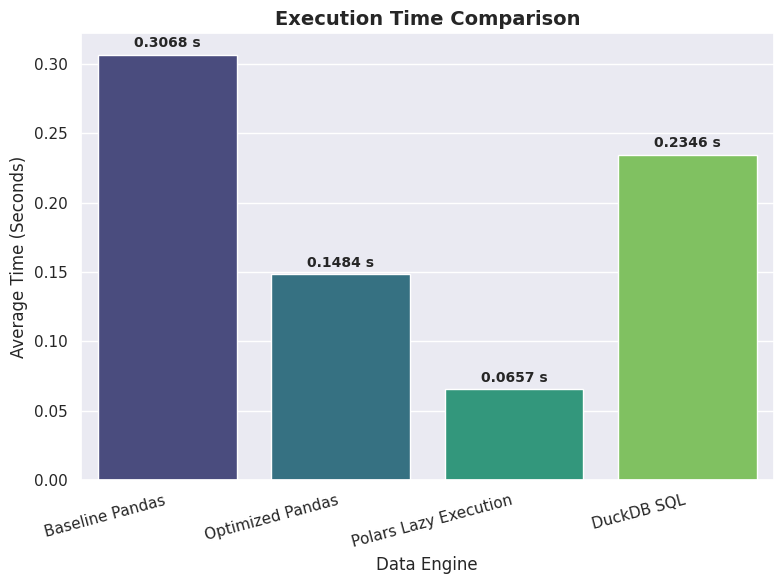

In [27]:
# 2. Configure visualization styling and subplots
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))

# --- Plot 1: Execution Time Metric Comparison
ax = sns.barplot(
        x="method",
        y="avg_time_sec",
        data=df_all,
        palette="viridis",
        hue="method",
        errorbar=None,
        legend=False
    )
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f s', padding=3, fontsize=10, fontweight='bold')

plt.title("Execution Time Comparison", fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha="right")
plt.ylabel("Average Time (Seconds)", fontsize=12)
plt.xlabel("Data Engine", fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HPDP project/p2/execution_time_comparison.png', dpi=150)
plt.show()


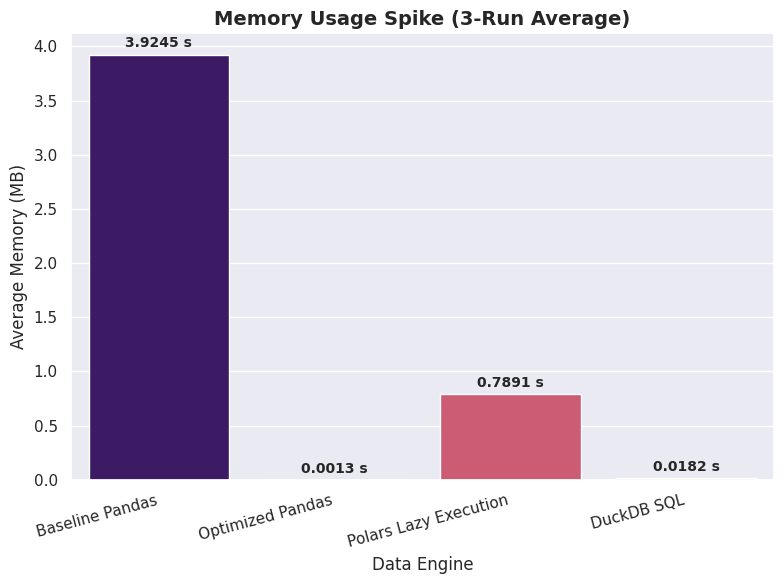

In [28]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))

# 2. Plot Memory Consumption Metric Comparison (Lower is Better)
ax = sns.barplot(
        x="method",
        y="avg_memory_mb",
        data=df_all,
        palette="magma",
        hue="method",
        errorbar=None,
        legend=False
    )
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f s', padding=3, fontsize=10, fontweight='bold')

plt.title("Memory Usage Spike (3-Run Average)", fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha="right")
plt.ylabel("Average Memory (MB)", fontsize=12)
plt.xlabel("Data Engine", fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HPDP project/p2/memory_usage_comparison.png', dpi=150)
plt.show()

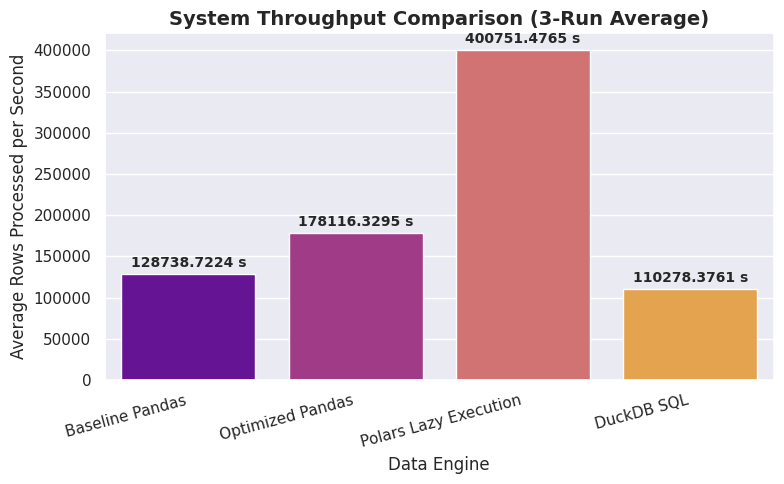

In [29]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 5))

# 2. Plot Throughput Metric Comparison (HIGHER is Better! )
ax = sns.barplot(
        x="method",
        y="avg_throughput",
        data=df_all,
        palette="plasma",
        hue="method",
        errorbar=None,
        legend=False
    )
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f s', padding=3, fontsize=10, fontweight='bold')

plt.title("System Throughput Comparison (3-Run Average)", fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha="right")
plt.ylabel("Average Rows Processed per Second", fontsize=12)
plt.xlabel("Data Engine", fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HPDP project/p2/throughput_comparison.png', dpi=150)
plt.show()

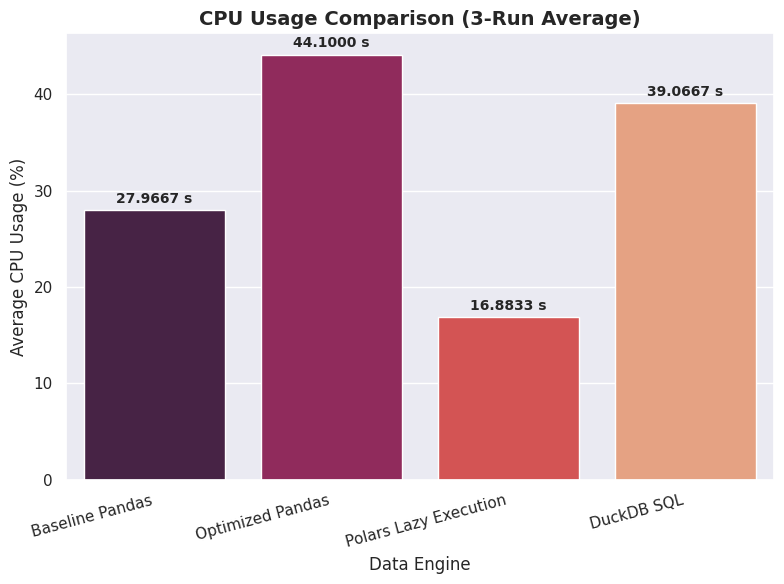

In [30]:
# 2. Configure visualization styling for CPU Usage Bar Chart
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))

# 3. Plot CPU Concurrency Level Comparison (Higher indicates better multi-core hardware utilization)
ax = sns.barplot(
        x="method",
        y="avg_cpu_%",
        data=df_all,
        palette="rocket",
        hue="method",
        errorbar=None,
        legend=False
    )
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f s', padding=3, fontsize=10, fontweight='bold')

# 4. Customize chart labels, ticks, and titles
plt.title("CPU Usage Comparison (3-Run Average)", fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha="right")
plt.ylabel("Average CPU Usage (%)", fontsize=12)
plt.xlabel("Data Engine", fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HPDP project/p2/cpu_usage_comparison.png', dpi=150)
plt.show()